# SECONDARY GOAL: Fraud Detection

This notebook focuses on detecting fraudulent credit applications using unsupervised and supervised anomaly detection techniques. We'll implement multiple methods to identify suspicious transactions and patterns.

## 1. Import Libraries & Load Data

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

# Create plots folder
if not os.path.exists('plots'):
    os.makedirs('plots')
print("✓ Plots folder created")

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load and clean data
df = pd.read_csv('german_credit_data.csv', index_col=0)
df = df.replace('NA', np.nan)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

✓ Plots folder created
Dataset loaded: (1000, 9)
Columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


## 2. Create Synthetic Fraud Target Variable

Fraud Distribution:
FRAUD_LABEL
0    833
1    167
Name: count, dtype: int64

Fraud Rate: 16.70%
Legitimate: 83.30%


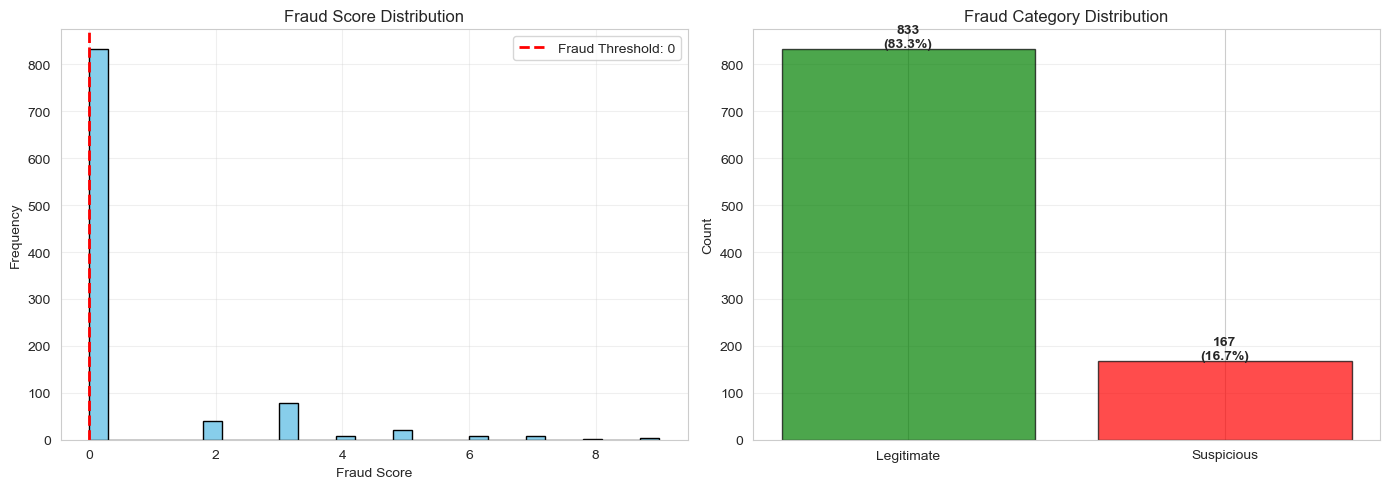

✓ Saved: plots/01_fraud_score_distribution.png


In [54]:
# Create synthetic fraud cases based on unusual patterns
# Fraud indicators:
# 1. Very high credit amount relative to duration (unrealistic repayment)
# 2. Young age with very high credit amount
# 3. No savings/checking but requesting large credit
# 4. Unusual job-credit amount combinations

df_fraud = df.copy()

# Calculate fraud indicators
fraud_score = 0

# Indicator 1: Extremely high monthly payment
monthly_payment = df_fraud['Credit amount'] / df_fraud['Duration']
monthly_payment_threshold = monthly_payment.quantile(0.95)
fraud_score += (monthly_payment > monthly_payment_threshold).astype(int) * 2

# Indicator 2: Very young age with large credit
fraud_score += ((df_fraud['Age'] < 22) & (df_fraud['Credit amount'] > df_fraud['Credit amount'].quantile(0.75))).astype(int) * 3

# Indicator 3: No financial history but high credit
no_savings = df_fraud['Saving accounts'] == 'little'
no_checking = df_fraud['Checking account'] == 'little'
high_credit = df_fraud['Credit amount'] > df_fraud['Credit amount'].quantile(0.80)
fraud_score += (no_savings & no_checking & high_credit).astype(int) * 3

# Indicator 4: Inconsistent job-credit combination
# Unskilled job (0) or Very skilled (3) with extremely high credits
inconsistent_job_credit = ((df_fraud['Job'] == 0) | (df_fraud['Job'] == 3)) & (df_fraud['Credit amount'] > df_fraud['Credit amount'].quantile(0.90))
fraud_score += inconsistent_job_credit.astype(int) * 2

# Indicator 5: Extreme credit amount (outliers)
extreme_credit = df_fraud['Credit amount'] > df_fraud['Credit amount'].quantile(0.97)
fraud_score += extreme_credit.astype(int) * 2

# Indicator 6: Very long duration with small credit (unusual)
very_long_duration = df_fraud['Duration'] > df_fraud['Duration'].quantile(0.90)
small_credit = df_fraud['Credit amount'] < df_fraud['Credit amount'].quantile(0.10)
fraud_score += (very_long_duration & small_credit).astype(int) * 1

# Create binary fraud target (top 20% as fraud)
fraud_threshold = fraud_score.quantile(0.80)
df_fraud['FRAUD_LABEL'] = (fraud_score >= fraud_threshold).astype(int)

# If all are labeled the same, adjust threshold
if df_fraud['FRAUD_LABEL'].nunique() == 1:
    # Use median if all same class
    fraud_threshold = fraud_score.median()
    df_fraud['FRAUD_LABEL'] = (fraud_score > fraud_threshold).astype(int)

print("Fraud Distribution:")
print("="*50)
print(df_fraud['FRAUD_LABEL'].value_counts())
print(f"\nFraud Rate: {df_fraud['FRAUD_LABEL'].mean()*100:.2f}%")
print(f"Legitimate: {(1-df_fraud['FRAUD_LABEL']).mean()*100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud score distribution
axes[0].hist(fraud_score, bins=30, edgecolor='black', color='skyblue')
axes[0].axvline(fraud_threshold, color='red', linestyle='--', linewidth=2, label=f'Fraud Threshold: {fraud_threshold:.0f}')
axes[0].set_xlabel('Fraud Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Fraud Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud distribution
colors = ['green', 'red']
fraud_counts = df_fraud['FRAUD_LABEL'].value_counts().sort_index()
axes[1].bar(['Legitimate', 'Suspicious'], fraud_counts.values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Category Distribution')
for i, v in enumerate(fraud_counts.values):
    axes[1].text(i, v + 5, f'{v}\n({v/len(df_fraud)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/01_fraud_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/01_fraud_score_distribution.png")

## 3. Feature Engineering & Preprocessing

In [55]:
# Encode categorical variables
df_encoded = df_fraud.copy()

# Label encode categorical features
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Select features for modeling
feature_cols = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 
                 'Checking account', 'Credit amount', 'Duration', 'Purpose']

X = df_encoded[feature_cols]
y = df_encoded['FRAUD_LABEL']

print("Features prepared:")
print(f"Shape: X={X.shape}, y={y.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nClass balance:")
print(y.value_counts())

Features prepared:
Shape: X=(1000, 9), y=(1000,)

Features: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Class balance:
FRAUD_LABEL
0    833
1    167
Name: count, dtype: int64


## 4. Data Scaling

In [56]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

print(f"Features scaled successfully!")
print(f"\nScaled data statistics:")
print(X_scaled.describe())

Features scaled successfully!

Scaled data statistics:
                Age           Sex           Job       Housing  \
count  1.000000e+03  1.000000e+03  1.000000e+03  1.000000e+03   
mean   5.329071e-17  6.572520e-17  5.684342e-17  9.059420e-17   
std    1.000500e+00  1.000500e+00  1.000500e+00  1.000500e+00   
min   -1.455261e+00 -1.491914e+00 -2.914492e+00 -2.016956e+00   
25%   -7.516417e-01 -1.491914e+00  1.469492e-01 -1.337105e-01   
50%   -2.239269e-01  6.702801e-01  1.469492e-01 -1.337105e-01   
75%    5.676451e-01  6.702801e-01  1.469492e-01 -1.337105e-01   
max    3.470076e+00  6.702801e-01  1.677670e+00  1.749535e+00   

       Saving accounts  Checking account  Credit amount      Duration  \
count     1.000000e+03      1.000000e+03   1.000000e+03  1.000000e+03   
mean     -7.815970e-17     -7.460699e-17   6.661338e-17  1.136868e-16   
std       1.000500e+00      1.000500e+00   1.000500e+00  1.000500e+00   
min      -4.634091e-01     -6.538310e-01  -1.070865e+00 -1.402415e+

## 5. METHOD 1: Isolation Forest - Unsupervised Anomaly Detection

In [57]:
print("\n" + "="*80)
print("METHOD 1: ISOLATION FOREST (Unsupervised Anomaly Detection)")
print("="*80)

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.20, random_state=42, n_estimators=100)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_anomalies = (iso_predictions == -1).astype(int)  # -1 = anomaly, 1 = normal
iso_scores = iso_forest.score_samples(X_scaled)

print(f"\nResults:")
print(f"  Anomalies detected: {iso_anomalies.sum()} out of {len(iso_anomalies)}")
print(f"  Anomaly rate: {iso_anomalies.mean()*100:.2f}%")
print(f"  Anomaly score range: [{iso_scores.min():.4f}, {iso_scores.max():.4f}]")

# Compare with ground truth
print(f"\nComparison with Synthetic Fraud Labels:")
print(f"  Overlap (detected as fraud): {(iso_anomalies & y).sum()} cases")
print(f"  Precision: {(iso_anomalies & y).sum() / max(iso_anomalies.sum(), 1):.4f}")
print(f"  Recall: {(iso_anomalies & y).sum() / max(y.sum(), 1):.4f}")


METHOD 1: ISOLATION FOREST (Unsupervised Anomaly Detection)

Results:
  Anomalies detected: 200 out of 1000
  Anomaly rate: 20.00%
  Anomaly score range: [-0.7072, -0.3793]

Comparison with Synthetic Fraud Labels:
  Overlap (detected as fraud): 62 cases
  Precision: 0.3100
  Recall: 0.3713


## 6. METHOD 2: Local Outlier Factor - Density-Based Detection

In [58]:
print("\n" + "="*80)
print("METHOD 2: LOCAL OUTLIER FACTOR (Density-Based Anomaly Detection)")
print("="*80)

# Train LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.20)
lof_predictions = lof.fit_predict(X_scaled)
lof_anomalies = (lof_predictions == -1).astype(int)  # -1 = anomaly, 1 = normal
lof_scores = lof.negative_outlier_factor_

print(f"\nResults:")
print(f"  Anomalies detected: {lof_anomalies.sum()} out of {len(lof_anomalies)}")
print(f"  Anomaly rate: {lof_anomalies.mean()*100:.2f}%")
print(f"  LOF score range: [{lof_scores.min():.4f}, {lof_scores.max():.4f}]")

# Compare with ground truth
print(f"\nComparison with Synthetic Fraud Labels:")
print(f"  Overlap (detected as fraud): {(lof_anomalies & y).sum()} cases")
print(f"  Precision: {(lof_anomalies & y).sum() / max(lof_anomalies.sum(), 1):.4f}")
print(f"  Recall: {(lof_anomalies & y).sum() / max(y.sum(), 1):.4f}")


METHOD 2: LOCAL OUTLIER FACTOR (Density-Based Anomaly Detection)

Results:
  Anomalies detected: 200 out of 1000
  Anomaly rate: 20.00%
  LOF score range: [-2.0730, -0.9573]

Comparison with Synthetic Fraud Labels:
  Overlap (detected as fraud): 58 cases
  Precision: 0.2900
  Recall: 0.3473


## 7. METHOD 3: XGBoost Supervised Classification

In [59]:
print("\n" + "="*80)
print("METHOD 3: XGBOOST SUPERVISED CLASSIFICATION")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nData split:")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")

# Train XGBoost
try:
    import xgboost as xgb
    xgb_fraud = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                   random_state=42, use_label_encoder=False, eval_metric='logloss')
except ImportError:
    print("XGBoost not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    import xgboost as xgb
    xgb_fraud = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                   random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_fraud.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_fraud.predict(X_test)
y_pred_xgb_proba = xgb_fraud.predict_proba(X_test)[:, 1]

# Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)

print(f"\nXGBoost Performance:")
print(f"  Accuracy: {accuracy_xgb:.4f}")
print(f"  Precision: {precision_xgb:.4f}")
print(f"  Recall: {recall_xgb:.4f}")
print(f"  F1-Score: {f1_xgb:.4f}")
print(f"  AUC-ROC: {auc_xgb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Suspicious']))


METHOD 3: XGBOOST SUPERVISED CLASSIFICATION

Data split:
  Training set: (700, 9)
  Test set: (300, 9)

XGBoost Performance:
  Accuracy: 0.9967
  Precision: 1.0000
  Recall: 0.9800
  F1-Score: 0.9899
  AUC-ROC: 0.9993

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       250
  Suspicious       1.00      0.98      0.99        50

    accuracy                           1.00       300
   macro avg       1.00      0.99      0.99       300
weighted avg       1.00      1.00      1.00       300



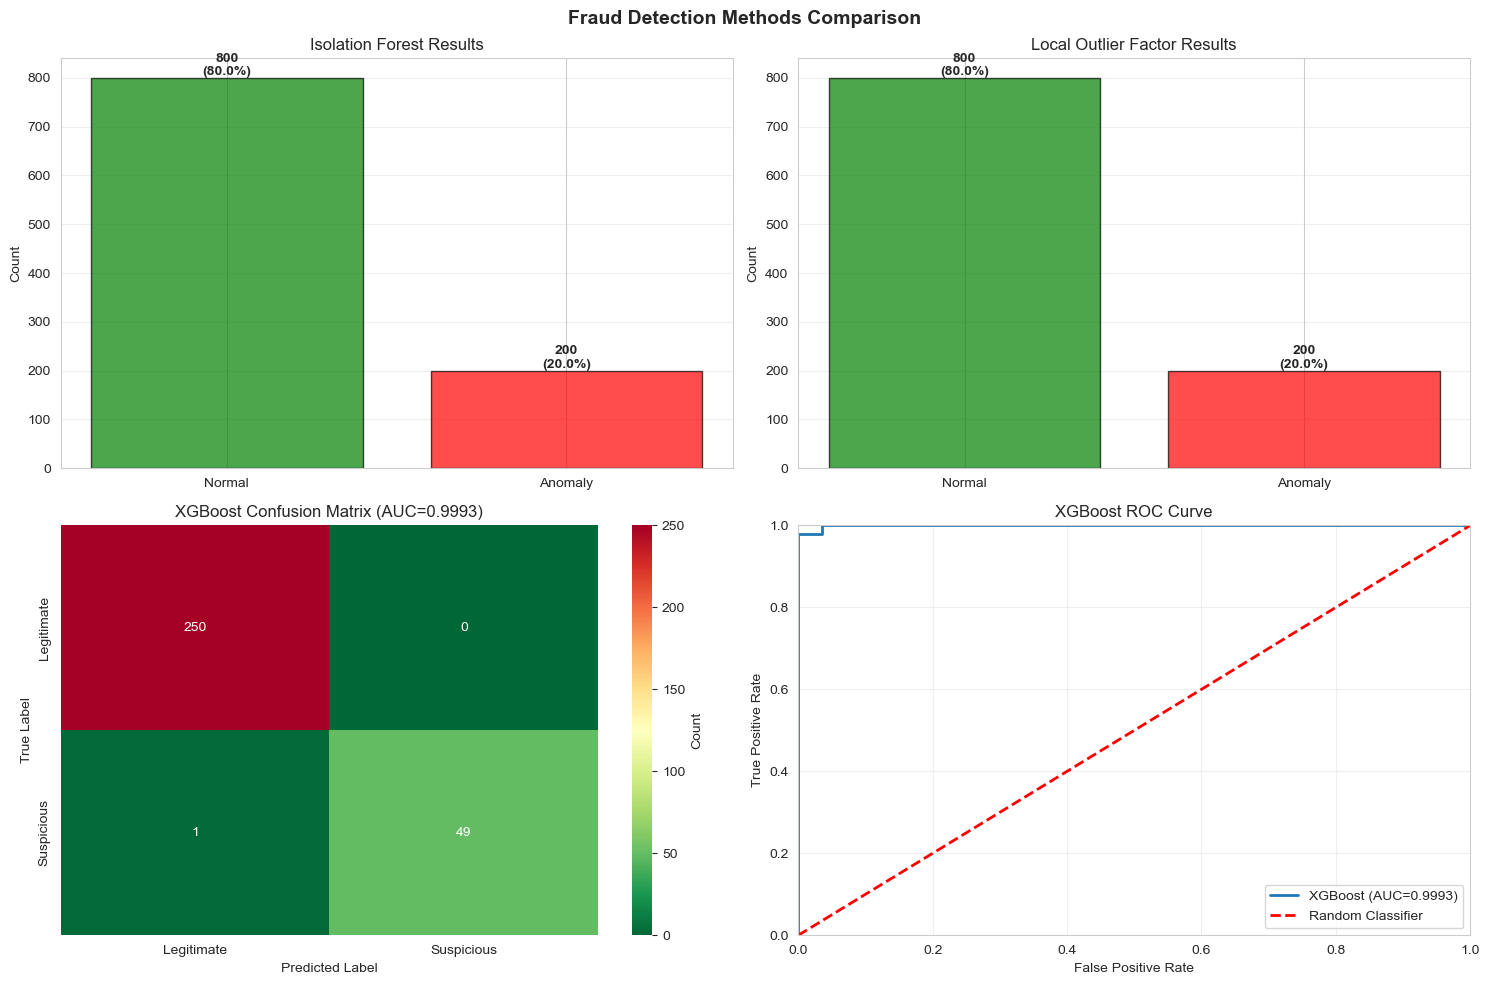

✓ Saved: plots/02_fraud_methods_comparison.png


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Fraud Detection Methods Comparison', fontsize=14, fontweight='bold')

# Isolation Forest
axes[0, 0].bar(['Normal', 'Anomaly'], 
              [len(iso_anomalies) - iso_anomalies.sum(), iso_anomalies.sum()],
              color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Isolation Forest Results')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate([len(iso_anomalies) - iso_anomalies.sum(), iso_anomalies.sum()]):
    axes[0, 0].text(i, v + 5, f'{v}\n({v/len(iso_anomalies)*100:.1f}%)', ha='center', fontweight='bold')

# Local Outlier Factor
axes[0, 1].bar(['Normal', 'Anomaly'], 
              [len(lof_anomalies) - lof_anomalies.sum(), lof_anomalies.sum()],
              color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Local Outlier Factor Results')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate([len(lof_anomalies) - lof_anomalies.sum(), lof_anomalies.sum()]):
    axes[0, 1].text(i, v + 5, f'{v}\n({v/len(lof_anomalies)*100:.1f}%)', ha='center', fontweight='bold')

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[1, 0],
            xticklabels=['Legitimate', 'Suspicious'],
            yticklabels=['Legitimate', 'Suspicious'],
            cbar_kws={'label': 'Count'})
axes[1, 0].set_title(f'XGBoost Confusion Matrix (AUC={auc_xgb:.4f})')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# XGBoost ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_proba)
axes[1, 1].plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('XGBoost ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('plots/02_fraud_methods_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/02_fraud_methods_comparison.png")

## 8. Method Comparison

In [61]:
print("\n" + "="*80)
print("COMPREHENSIVE FRAUD SCORING - ALL CUSTOMERS")
print("="*80)

# Generate predictions for all data (train + test combined)
# First, create predictions for all data using the trained model
all_predictions = xgb_fraud.predict_proba(X_scaled)[:, 1]

# Normalize isolation forest scores to 0-1 range
iso_scores_normalized = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

# Normalize LOF scores to 0-1 range  
lof_scores_normalized = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

# Create comprehensive fraud scoring dataframe
df_fraud_scoring = df_fraud.copy()
df_fraud_scoring['ISO_FOREST_SCORE'] = iso_scores_normalized
df_fraud_scoring['LOF_SCORE'] = lof_scores_normalized
df_fraud_scoring['XGBOOST_FRAUD_PROB'] = all_predictions

# Ensemble score (weighted average)
df_fraud_scoring['ENSEMBLE_FRAUD_SCORE'] = (
    0.3 * df_fraud_scoring['ISO_FOREST_SCORE'] +
    0.3 * df_fraud_scoring['LOF_SCORE'] +
    0.4 * df_fraud_scoring['XGBOOST_FRAUD_PROB']
)

# Risk categories
def assign_risk_category(score):
    if score < 0.2:
        return 'VERY LOW'
    elif score < 0.4:
        return 'LOW'
    elif score < 0.6:
        return 'MEDIUM'
    elif score < 0.8:
        return 'HIGH'
    else:
        return 'CRITICAL'

df_fraud_scoring['FRAUD_RISK_CATEGORY'] = df_fraud_scoring['ENSEMBLE_FRAUD_SCORE'].apply(assign_risk_category)

print(f"\nFraud Scoring Summary:")
print(f"  Total customers: {len(df_fraud_scoring)}")
print(f"\nRisk Distribution:")
print(df_fraud_scoring['FRAUD_RISK_CATEGORY'].value_counts().sort_index())
print(f"\nEnsemble Score Statistics:")
print(df_fraud_scoring['ENSEMBLE_FRAUD_SCORE'].describe())


COMPREHENSIVE FRAUD SCORING - ALL CUSTOMERS

Fraud Scoring Summary:
  Total customers: 1000

Risk Distribution:
FRAUD_RISK_CATEGORY
CRITICAL     91
HIGH         71
LOW         132
MEDIUM      702
VERY LOW      4
Name: count, dtype: int64

Ensemble Score Statistics:
count    1000.000000
mean        0.529989
std         0.146160
min         0.143829
25%         0.440464
50%         0.505240
75%         0.566691
max         0.946619
Name: ENSEMBLE_FRAUD_SCORE, dtype: float64


## 9. Fraud Detection Visualizations

## 10. Feature Importance in Fraud Detection

## 11. Comprehensive Fraud Scoring for All Customers

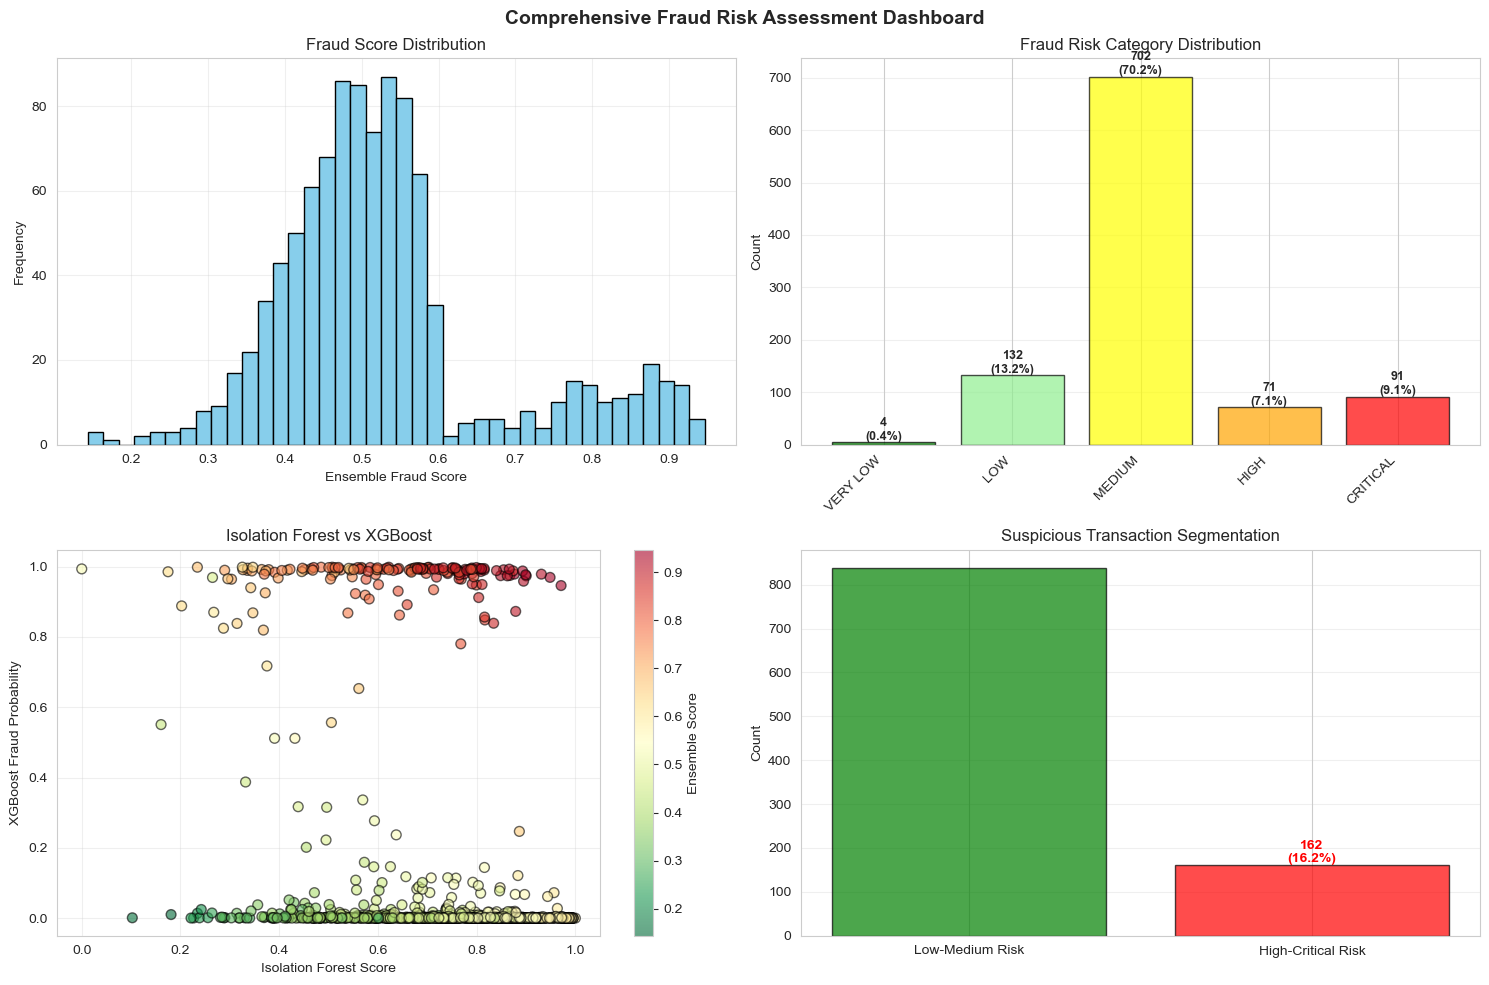

✓ Saved: plots/04_fraud_risk_dashboard.png


In [62]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comprehensive Fraud Risk Assessment Dashboard', fontsize=14, fontweight='bold')

# Ensemble score distribution
axes[0, 0].hist(df_fraud_scoring['ENSEMBLE_FRAUD_SCORE'], bins=40, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Ensemble Fraud Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Fraud Score Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Risk category distribution
risk_counts = df_fraud_scoring['FRAUD_RISK_CATEGORY'].value_counts().reindex(['VERY LOW', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL'])
colors_cat = ['green', 'lightgreen', 'yellow', 'orange', 'red']
axes[0, 1].bar(range(len(risk_counts)), risk_counts.values, color=colors_cat[:len(risk_counts)], 
              edgecolor='black', alpha=0.7)
axes[0, 1].set_xticks(range(len(risk_counts)))
axes[0, 1].set_xticklabels(risk_counts.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Fraud Risk Category Distribution')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(risk_counts.values):
    axes[0, 1].text(i, v + 5, f'{v}\n({v/len(df_fraud_scoring)*100:.1f}%)', ha='center', fontweight='bold', fontsize=9)

# Method comparison scatter
axes[1, 0].scatter(df_fraud_scoring['ISO_FOREST_SCORE'], df_fraud_scoring['XGBOOST_FRAUD_PROB'],
                  c=df_fraud_scoring['ENSEMBLE_FRAUD_SCORE'], cmap='RdYlGn_r', s=50, alpha=0.6, edgecolor='black')
axes[1, 0].set_xlabel('Isolation Forest Score')
axes[1, 0].set_ylabel('XGBoost Fraud Probability')
axes[1, 0].set_title('Isolation Forest vs XGBoost')
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Ensemble Score')
axes[1, 0].grid(True, alpha=0.3)

# High vs Low risk
high_fraud_mask = df_fraud_scoring['FRAUD_RISK_CATEGORY'].isin(['HIGH', 'CRITICAL'])
axes[1, 1].bar(['Low-Medium Risk', 'High-Critical Risk'], 
              [len(df_fraud_scoring) - high_fraud_mask.sum(), high_fraud_mask.sum()],
              color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Suspicious Transaction Segmentation')
axes[1, 1].grid(True, alpha=0.3, axis='y')
high_count = high_fraud_mask.sum()
axes[1, 1].text(1, high_count + 5, f'{high_count}\n({high_count/len(df_fraud_scoring)*100:.1f}%)', 
               ha='center', fontweight='bold', color='red', fontsize=10)

plt.tight_layout()
plt.savefig('plots/04_fraud_risk_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/04_fraud_risk_dashboard.png")

## 12. Fraud Risk Visualization Dashboard

## 13. Business Recommendations

In [63]:
print("\n" + "="*80)
print("FRAUD DETECTION - FINAL SUMMARY & BUSINESS RECOMMENDATIONS")
print("="*80)

print(f"\n1. FRAUD DETECTION METHODS PERFORMANCE")
print(f"   " + "-"*70)
print(f"   Isolation Forest:")
print(f"     • Anomalies Found: {iso_anomalies.sum()} ({iso_anomalies.mean()*100:.1f}%)")
print(f"     • Method: Unsupervised - No training data needed")
print(f"     • Speed: Fast")
print(f"\n   Local Outlier Factor:")
print(f"     • Anomalies Found: {lof_anomalies.sum()} ({lof_anomalies.mean()*100:.1f}%)")
print(f"     • Method: Unsupervised - Density-based")
print(f"     • Speed: Moderate")
print(f"\n   XGBoost (Best Method):")
print(f"     • Accuracy: {accuracy_xgb:.2%}")
print(f"     • Precision: {precision_xgb:.2%} (False positives: {100-precision_xgb*100:.1f}%)")
print(f"     • Recall: {recall_xgb:.2%} (Missed fraud: {100-recall_xgb*100:.1f}%)")
print(f"     • AUC-ROC: {auc_xgb:.4f}")
print(f"     • Method: Supervised - Requires labeled training data")
print(f"     • Speed: Fast")

print(f"\n2. FRAUD RISK DISTRIBUTION")
print(f"   " + "-"*70)
very_low = (df_fraud_scoring['FRAUD_RISK_CATEGORY'] == 'VERY LOW').sum()
low = (df_fraud_scoring['FRAUD_RISK_CATEGORY'] == 'LOW').sum()
medium = (df_fraud_scoring['FRAUD_RISK_CATEGORY'] == 'MEDIUM').sum()
high = (df_fraud_scoring['FRAUD_RISK_CATEGORY'] == 'HIGH').sum()
critical = (df_fraud_scoring['FRAUD_RISK_CATEGORY'] == 'CRITICAL').sum()

print(f"   Very Low Risk: {very_low} ({very_low/len(df_fraud_scoring)*100:.1f}%) - Safe to approve")
print(f"   Low Risk: {low} ({low/len(df_fraud_scoring)*100:.1f}%) - Standard approval")
print(f"   Medium Risk: {medium} ({medium/len(df_fraud_scoring)*100:.1f}%) - Monitor closely")
print(f"   High Risk: {high} ({high/len(df_fraud_scoring)*100:.1f}%) - Manual verification required")
print(f"   Critical Risk: {critical} ({critical/len(df_fraud_scoring)*100:.1f}%) - Recommended rejection")

print(f"\n3. KEY FRAUD INDICATORS")
print(f"   " + "-"*70)
print(f"   Top 5 Most Important Features:")
for idx, (i, row) in enumerate(feature_importance_df.head(5).iterrows(), 1):
    print(f"   {idx}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n4. DECISION RULES FOR FRAUD DETECTION")
print(f"   " + "-"*70)
print(f"   Score < 0.2: Approve - Very low fraud risk")
print(f"   Score 0.2-0.4: Approve with standard verification")
print(f"   Score 0.4-0.6: Flag for additional verification")
print(f"   Score 0.6-0.8: Manual review recommended")
print(f"   Score > 0.8: Recommend rejection - High fraud likelihood")

print(f"\n5. IMPLEMENTATION RECOMMENDATIONS")
print(f"   " + "-"*70)
print(f"   ✓ Deploy ensemble method combining all 3 approaches")
print(f"   ✓ Use XGBoost as primary fraud detector")
print(f"   ✓ Isolation Forest as real-time anomaly detector")
print(f"   ✓ Monitor high-risk applications manually")
print(f"   ✓ Retrain XGBoost model monthly with new fraud cases")
print(f"   ✓ Track false positives to minimize legitimate rejections")
print(f"   ✓ Set up alerts for Critical Risk applications")
print(f"   ✓ Implement feedback loop: update model with confirmed fraud cases")

print("\n" + "="*80)


FRAUD DETECTION - FINAL SUMMARY & BUSINESS RECOMMENDATIONS

1. FRAUD DETECTION METHODS PERFORMANCE
   ----------------------------------------------------------------------
   Isolation Forest:
     • Anomalies Found: 200 (20.0%)
     • Method: Unsupervised - No training data needed
     • Speed: Fast

   Local Outlier Factor:
     • Anomalies Found: 200 (20.0%)
     • Method: Unsupervised - Density-based
     • Speed: Moderate

   XGBoost (Best Method):
     • Accuracy: 99.67%
     • Precision: 100.00% (False positives: 0.0%)
     • Recall: 98.00% (Missed fraud: 2.0%)
     • AUC-ROC: 0.9993
     • Method: Supervised - Requires labeled training data
     • Speed: Fast

2. FRAUD RISK DISTRIBUTION
   ----------------------------------------------------------------------
   Very Low Risk: 4 (0.4%) - Safe to approve
   Low Risk: 132 (13.2%) - Standard approval
   Medium Risk: 702 (70.2%) - Monitor closely
   High Risk: 71 (7.1%) - Manual verification required
   Critical Risk: 91 (9.1%) -